# Credit Scoring Model
This notebook builds a complete Machine Learning pipeline to predict whether a customer is creditworthy using the German Credit Data dataset from UCI.

**Pipeline Steps:**
1. Import dataset
2. Exploratory Data Analysis (EDA)
3. Handle missing values
4. Remove duplicates
5. Encode categorical features
6. Feature Engineering
7. Feature Scaling
8. Train/Test Split
9. Train multiple models
10. Compare model performances
11. Evaluate the best model
12. Save trained model


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import joblib
import warnings
warnings.filterwarnings('ignore')


## 1. Import Dataset
We will download the German Credit dataset directly.


In [2]:
# Download the dataset using pandas
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data'
# The dataset has 20 features and 1 target variable
columns = ['status_checking_acc', 'duration_months', 'credit_history', 'purpose', 
           'credit_amount', 'savings_acc', 'employment_st', 'installment_rate', 
           'personal_status', 'other_debtors', 'residence_since', 'property', 
           'age_years', 'other_installment_plans', 'housing', 'existing_credits', 
           'job', 'num_dependents', 'telephone', 'foreign_worker', 'target']

df = pd.read_csv(url, sep=' ', header=None, names=columns)
df.to_csv('dataset/german_credit.csv', index=False)
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (1000, 21)


,status_checking_acc,duration_months,credit_history,purpose,credit_amount,savings_acc,employment_st,installment_rate,personal_status,other_debtors,...,property,age_years,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


## 2. Exploratory Data Analysis
Let's explore the data.


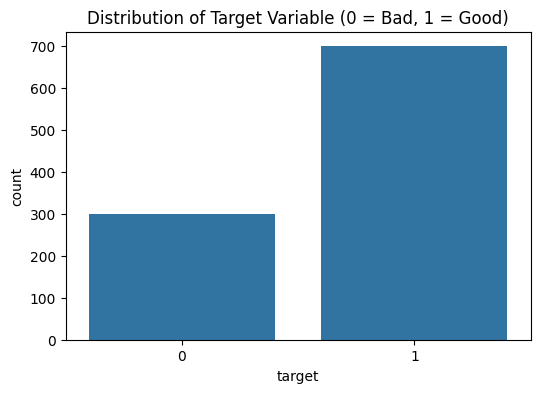

In [3]:
# Check target distribution
# Target mapping: 1 = Good, 2 = Bad -> We will map to 1 = Good, 0 = Bad
df['target'] = df['target'].map({1: 1, 2: 0})

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Distribution of Target Variable (0 = Bad, 1 = Good)')
plt.savefig('screenshots/target_distribution.png')
plt.show()


## 3. & 4. Handle Missing Values and Duplicates


In [4]:
# Check missing values
print("Missing values in each column:\n", df.isnull().sum())

# Drop duplicates if any
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
df.drop_duplicates(inplace=True)


Missing values in each column:
 status_checking_acc        0
duration_months            0
credit_history             0
purpose                    0
credit_amount              0
savings_acc                0
employment_st              0
installment_rate           0
personal_status            0
other_debtors              0
residence_since            0
property                   0
age_years                  0
other_installment_plans    0
housing                    0
existing_credits           0
job                        0
num_dependents             0
telephone                  0
foreign_worker             0
target                     0
dtype: int64
Number of duplicate rows: 0


## 5. Encode Categorical Features


In [5]:
categorical_cols = df.select_dtypes(include=['object']).columns

# We will use LabelEncoder for simplicity and standard processing
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("Categorical columns encoded.")
df.head()


Categorical columns encoded.


,status_checking_acc,duration_months,credit_history,purpose,credit_amount,savings_acc,employment_st,installment_rate,personal_status,other_debtors,...,property,age_years,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target
0,0,6,4,4,1169,4,4,4,2,0,...,0,67,2,1,2,2,1,1,0,1
1,1,48,2,4,5951,0,2,2,1,0,...,0,22,2,1,1,2,1,0,0,0
2,3,12,4,7,2096,0,3,2,2,0,...,0,49,2,1,1,1,2,0,0,1
3,0,42,2,3,7882,0,3,2,2,2,...,1,45,2,2,1,2,2,0,0,1
4,0,24,3,0,4870,0,2,3,2,0,...,3,53,2,2,2,2,2,0,0,0


## 6. & 7. Feature Engineering and Scaling


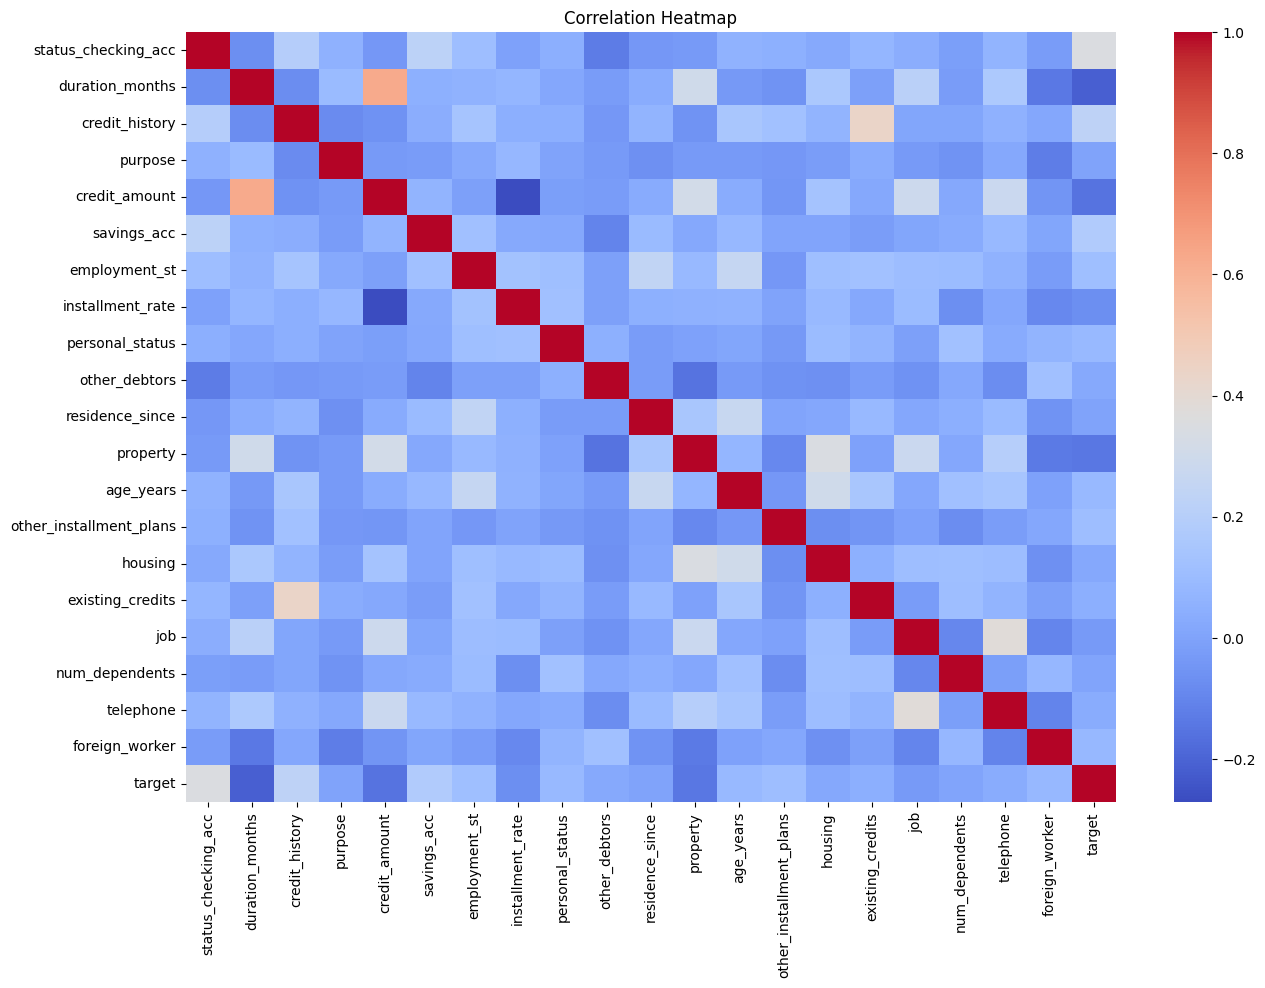

In [6]:
# Correlation heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('screenshots/correlation_heatmap.png')
plt.show()

# Split X and y
X = df.drop('target', axis=1)
y = df['target']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


## 8. Split Dataset into Train/Test


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (800, 20)
Testing set shape: (200, 20)


## 9. Train Multiple Models
We will train Logistic Regression, Decision Tree, and Random Forest.


In [8]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100)
}

# Train and evaluate models
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else [0]*len(y_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results)


## 10. & 11. Compare Performances & Select Best


In [9]:
print("Model Performance Comparison:")
display(results_df)

# Select best model based on F1 Score or ROC-AUC
best_model_name = results_df.loc[results_df['ROC-AUC'].idxmax()]['Model']
best_model = models[best_model_name]
print(f"\nBest Model selected: {best_model_name}")


Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.740,0.801370,0.835714,0.818182,0.782619
1,Decision Tree,0.725,0.797203,0.814286,0.805654,0.665476
2,Random Forest,0.785,0.808917,0.907143,0.855219,0.810357



Best Model selected: Random Forest


## 12. & 13. Evaluate Best Model & Plot Graphs


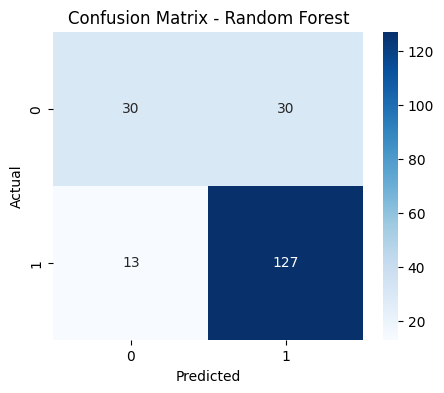

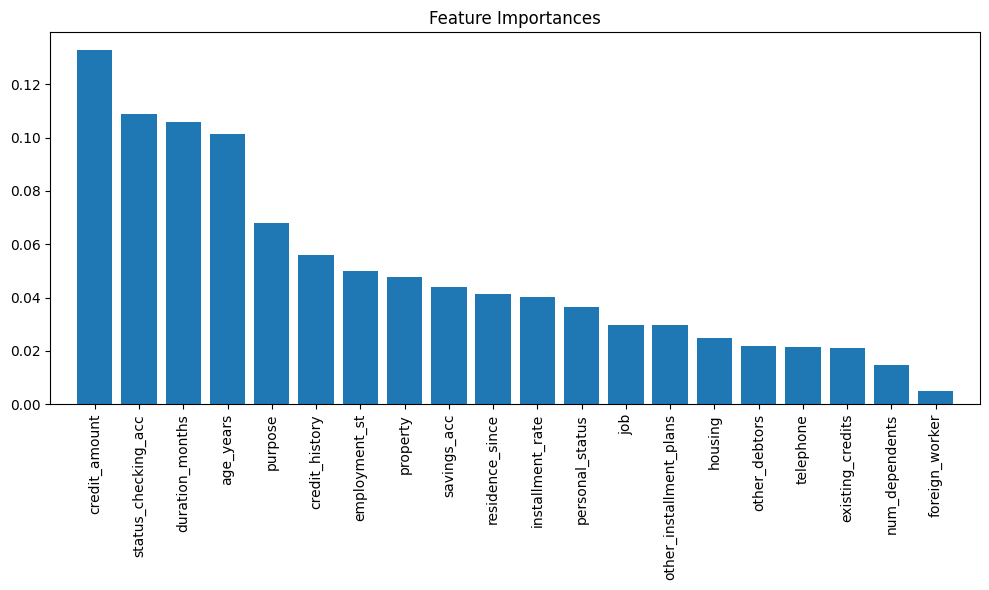

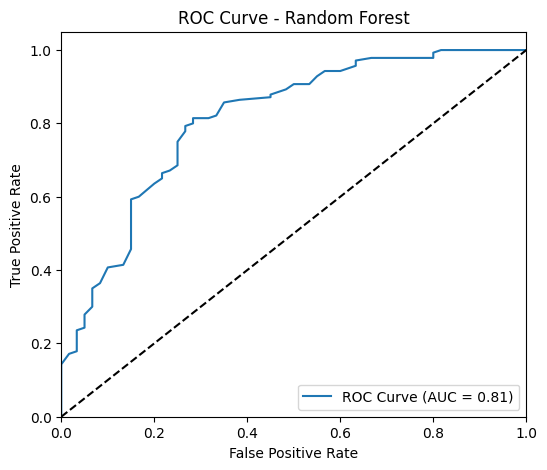

In [10]:
# Evaluate best model
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('screenshots/confusion_matrix.png')
plt.show()

# Feature Importance (if applicable)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(10, 6))
    plt.title("Feature Importances")
    plt.bar(range(X.shape[1]), importances[indices], align="center")
    plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
    plt.xlim([-1, X.shape[1]])
    plt.tight_layout()
    plt.savefig('screenshots/feature_importance.png')
    plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_model_name}')
plt.legend(loc="lower right")
plt.savefig('screenshots/roc_curve.png')
plt.show()


## 14. Save Trained Model


In [11]:
joblib.dump(best_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
# Save label encoders to use them later
joblib.dump(label_encoders, 'label_encoders.pkl')
print("Model and preprocessors saved successfully.")


Model and preprocessors saved successfully.


## 15. Prediction Example


In [12]:
# Example prediction
def predict_creditworthiness(customer_data):
    # Load models
    model = joblib.load('model.pkl')
    scaler = joblib.load('scaler.pkl')
    
    # Scale data
    scaled_data = scaler.transform([customer_data])
    
    # Predict
    pred = model.predict(scaled_data)
    prob = model.predict_proba(scaled_data)[:, 1]
    
    return "Creditworthy (Good)" if pred[0] == 1 else "Not Creditworthy (Bad)", prob[0]

# Let's take the first row of X_test (before scaling) to test
# Since we lost unscaled X_test, we'll take the first row of X
example_customer = X.iloc[0].values
status, probability = predict_creditworthiness(example_customer)
print(f"Prediction: {status}")
print(f"Probability of being creditworthy: {probability:.2f}")


Prediction: Creditworthy (Good)
Probability of being creditworthy: 0.95
